# Matrix-Function Spectral Baselines

This notebook benchmarks dense spectral matrix function (DSMF) references and polynomial matrix evaluation (PME) approximations for physics-style operators used in filtering, thermal weighting, and diffusion examples.

In [1]:
import json
from pathlib import Path

import numpy as np

from qsvt import (
    design_filter_polynomial,
    design_imaginary_time_polynomial,
    dirichlet_laplacian_1d,
    plot_benchmark_timings,
    plot_qsvt_proxy_resources,
    polynomial_matrix_function_benchmark,
    report_to_jsonable,
    save_report,
    spectral_matrix_function_benchmark,
    write_benchmark_summary_csv,
)


def find_repo_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("could not locate repository root")


ROOT = find_repo_root()
ARTIFACT_DIR = ROOT / "results/benchmarks"
TABLE_DIR = ROOT / "results/tables"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

## Heat-Flow And Filter Operators

## Quantum-Advantage Interpretation

DSMF diagonalizes the full operator, which is reliable for small validation problems but scales poorly for large sparse Hamiltonians or PDE discretizations. QSVT is most relevant when the target transformation admits a moderate-degree PME and the application only needs a transformed state, filtered subspace statistic, or expectation value. These benchmarks separate the exact classical spectral baseline from the polynomial/QSVT resource proxy so the degree and signal-call assumptions remain visible.

{
  "spectral_problem": "exponential-matrix-function",
  "thermal_degree": 10,
  "filter_degree": 10,
  "filter_qsvt_signal_calls": 10
}


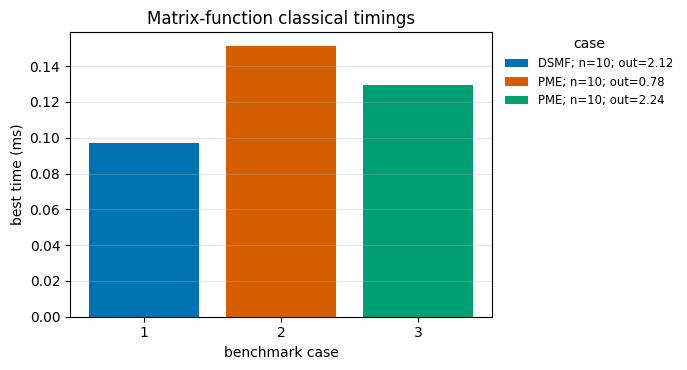

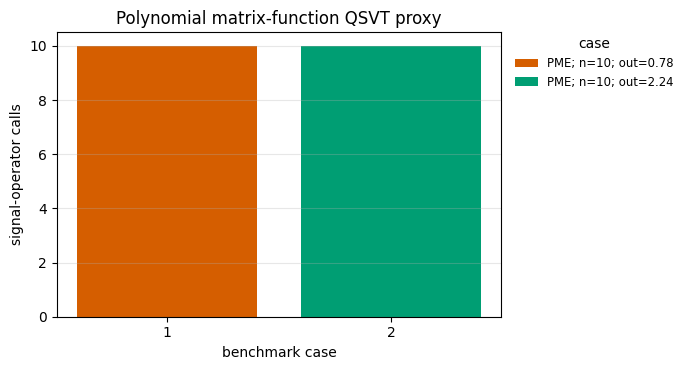

In [2]:
grid, operator = dirichlet_laplacian_1d(10)
scaled_operator = operator / np.max(np.linalg.eigvalsh(operator))

thermal = design_imaginary_time_polynomial(beta=1.0, scale=1.0, degree=10)
filter_coeffs = design_filter_polynomial(cutoff=0.35, degree=10, sharpness=10.0)

spectral_report = spectral_matrix_function_benchmark(
    scaled_operator,
    "exponential",
    beta=1.0,
    repeats=3,
)
thermal_poly_report = polynomial_matrix_function_benchmark(
    scaled_operator,
    thermal.coeffs,
    repeats=3,
)
filter_poly_report = polynomial_matrix_function_benchmark(
    scaled_operator,
    filter_coeffs,
    repeats=3,
)

reports = [spectral_report, thermal_poly_report, filter_poly_report]
save_report(spectral_report, ARTIFACT_DIR / "matrix_function_exponential_spectral.json")
save_report(
    thermal_poly_report, ARTIFACT_DIR / "matrix_function_thermal_polynomial.json"
)
save_report(filter_poly_report, ARTIFACT_DIR / "matrix_function_filter_polynomial.json")
write_benchmark_summary_csv(
    reports, TABLE_DIR / "matrix_function_benchmark_summary.csv"
)

summary = {
    "spectral_problem": spectral_report["problem"],
    "thermal_degree": thermal_poly_report["metrics"]["polynomial_degree"],
    "filter_degree": filter_poly_report["metrics"]["polynomial_degree"],
    "filter_qsvt_signal_calls": filter_poly_report["qsvt_proxy"]["resources"][
        "signal_operator_calls"
    ],
}
print(json.dumps(report_to_jsonable(summary), indent=2))

_ = plot_benchmark_timings(reports, title="Matrix-function classical timings")
_ = plot_qsvt_proxy_resources(reports, title="Polynomial matrix-function QSVT proxy")